# Correlations between the variables used for the fit

### Setting up the data and tools

In [3]:
# Importing the notebook with common setup 
%run 'bdt-all-common.ipynb'

Invoke (root_datasets, pandas_datasets) = load_data(inclmc_type="23903000") to load datasets
Invoke (root_datasets, pandas_datasets) = load_data(inclmc_type="23903003") to load dataset for double charm
Invoke  df_signal_23903000 = load_signal_from_inclMC() to load signal from 23903000 Inclusive MC
or
Invoke  df_signal = load_signal_all()
Invoke  df_background = load_background_category(category)
[14:23:23] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1679035063795/work/src/learner.cc:553: 
  If you are loading a serialized model (like pickle in Python, RDS in R) generated by
  older XGBoost, please export the model by calling `Booster.save_model` from that version
  first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/latest/tutorials/saving_model.html

  for more details about differences between saving model and serializing.

[14:23:23] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1679035063795/work/src/lea

In [4]:
import seaborn as sn
plt.rcParams["figure.figsize"] = (15,4)

## Correlations between the fit variables on the overall dataset

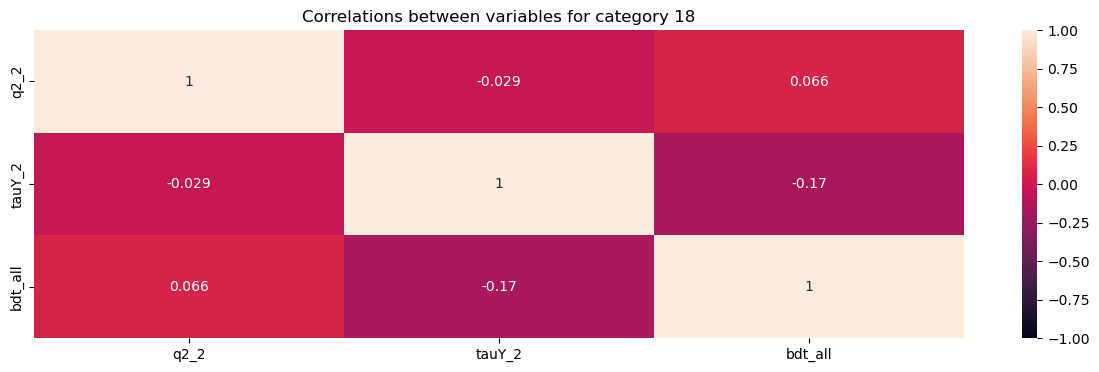

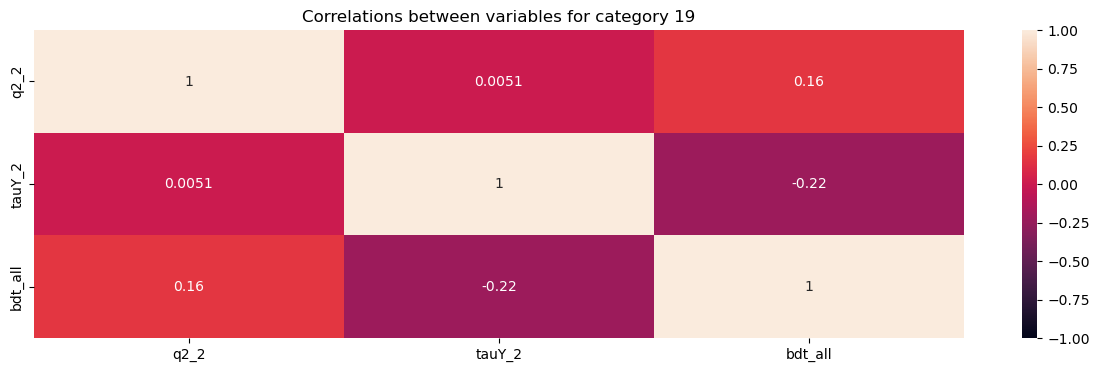

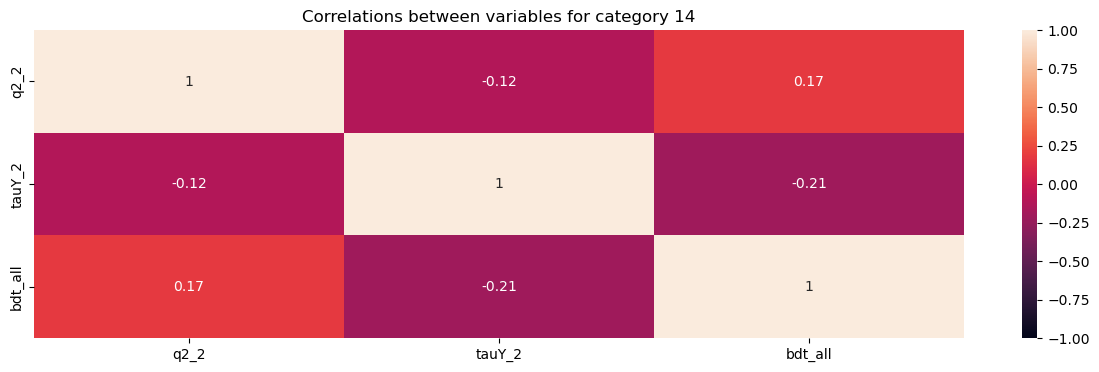

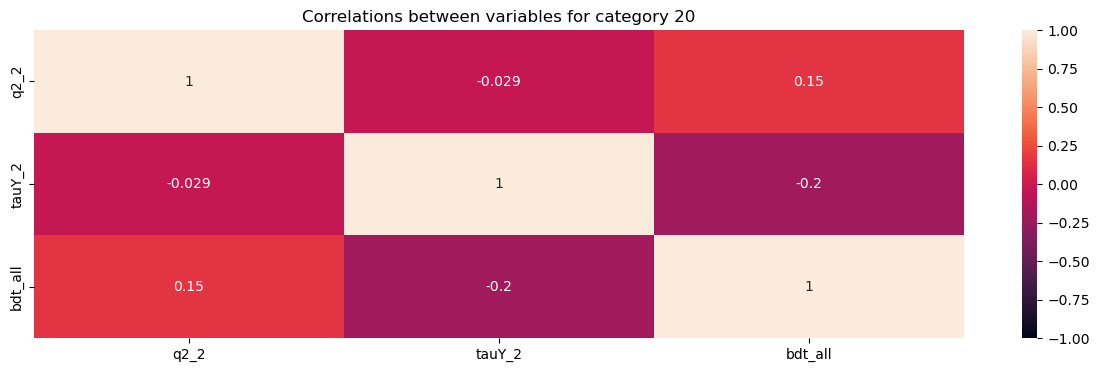

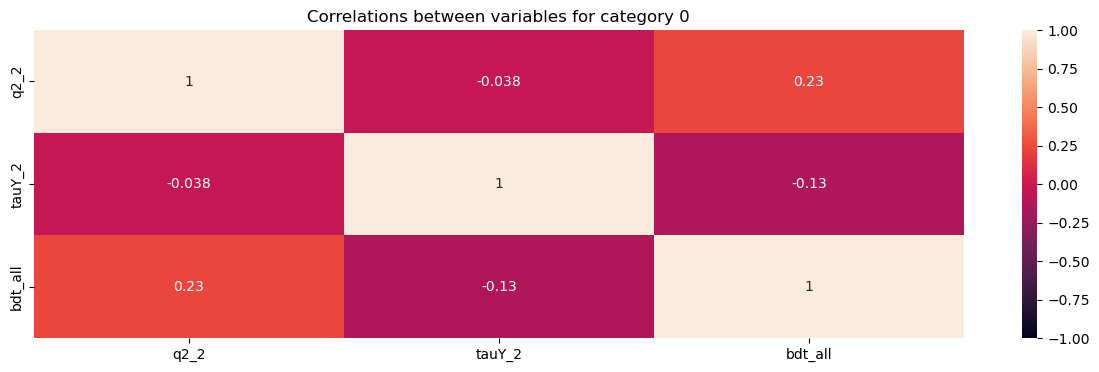

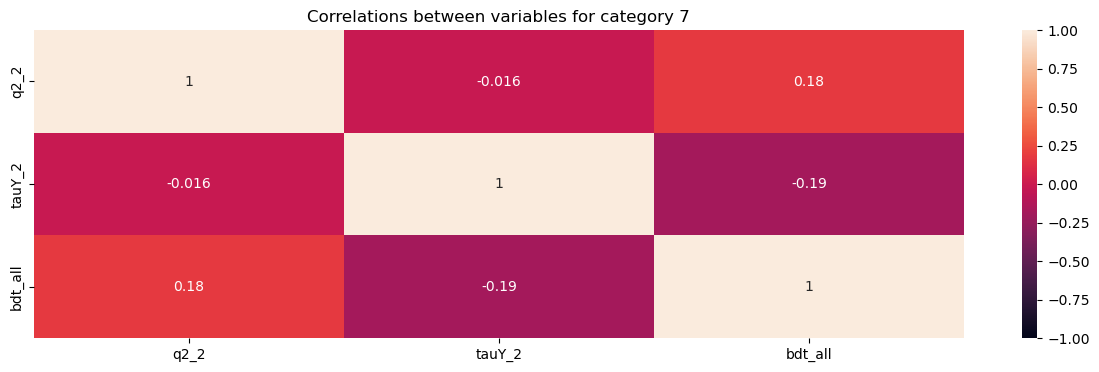

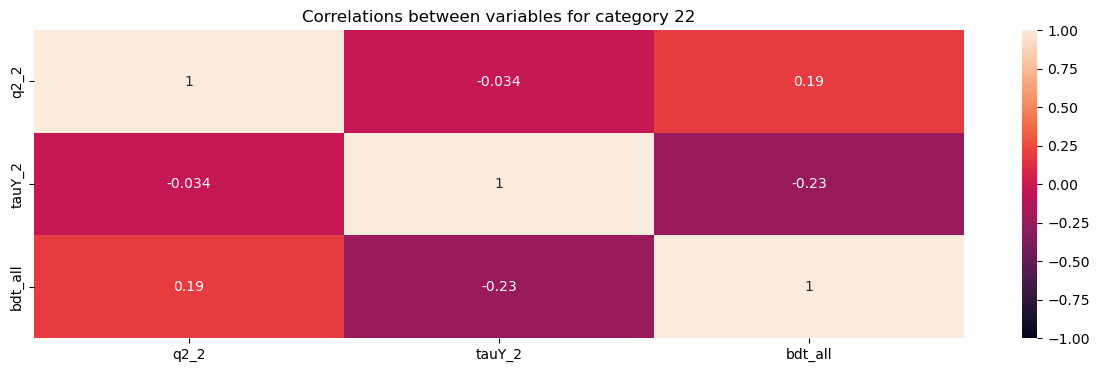

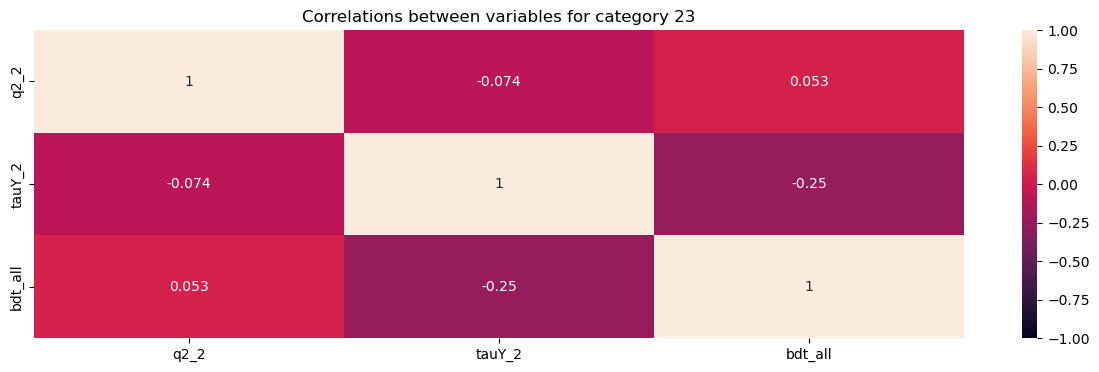

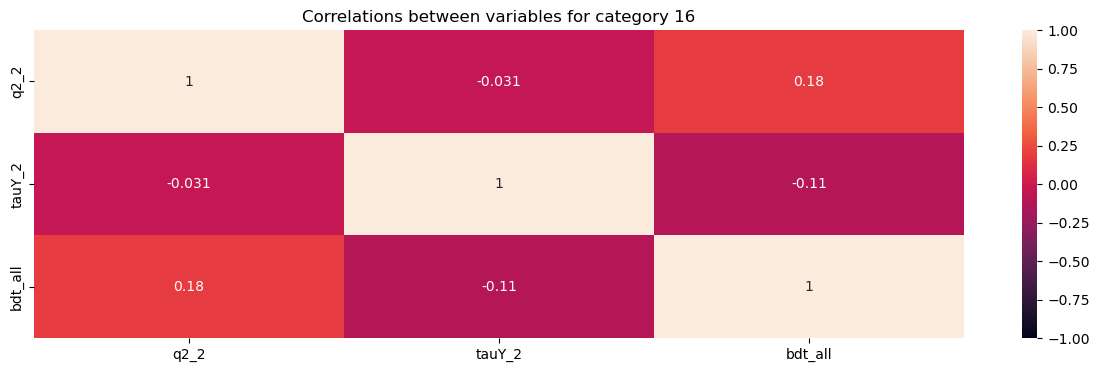

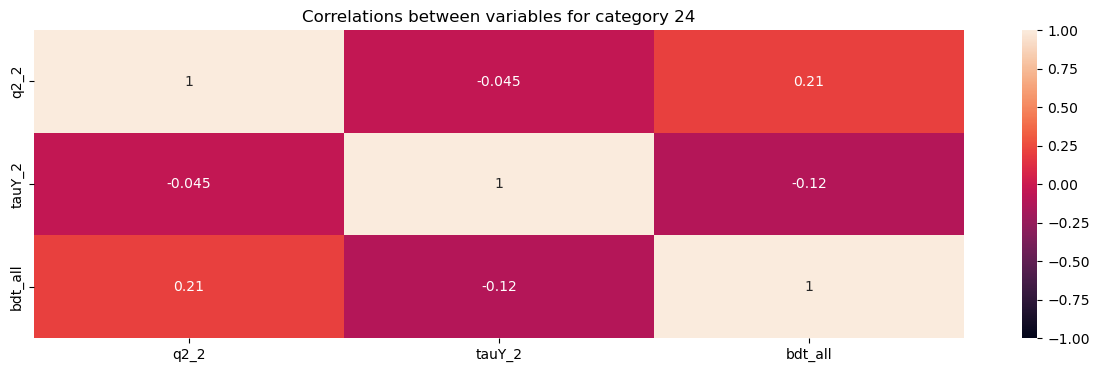

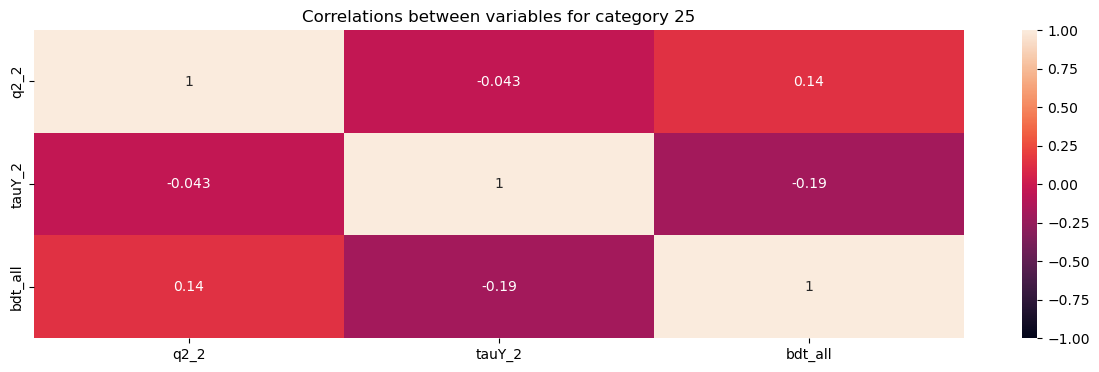

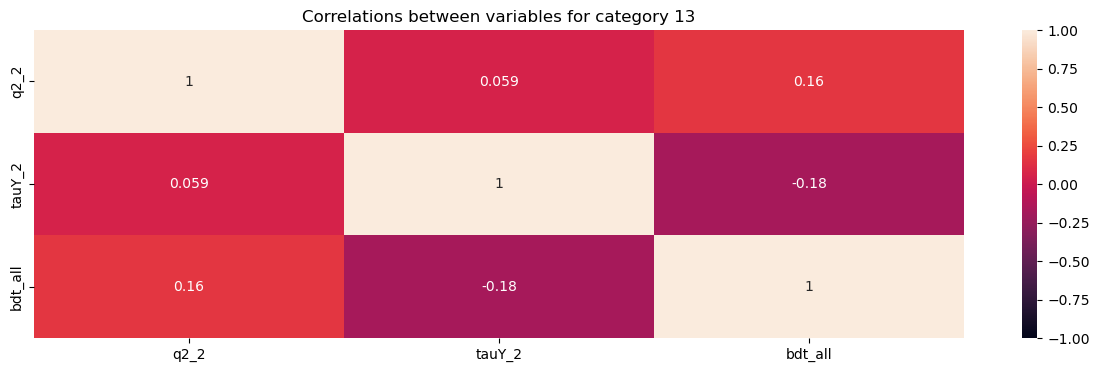

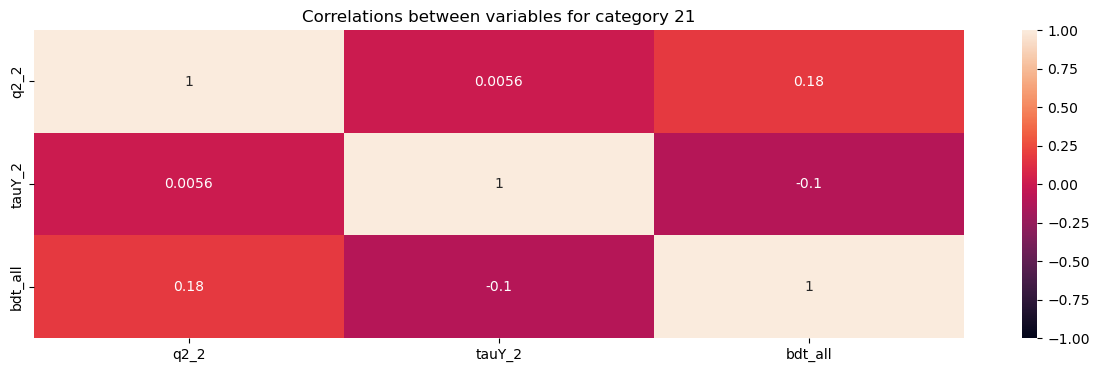

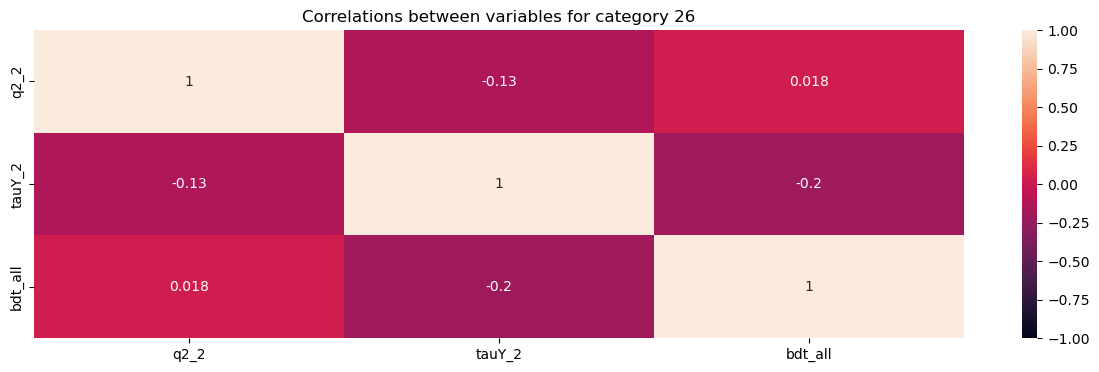

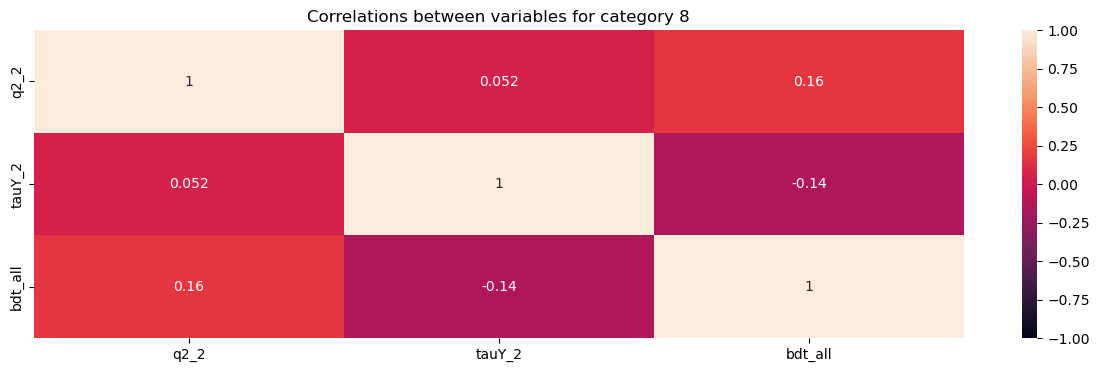

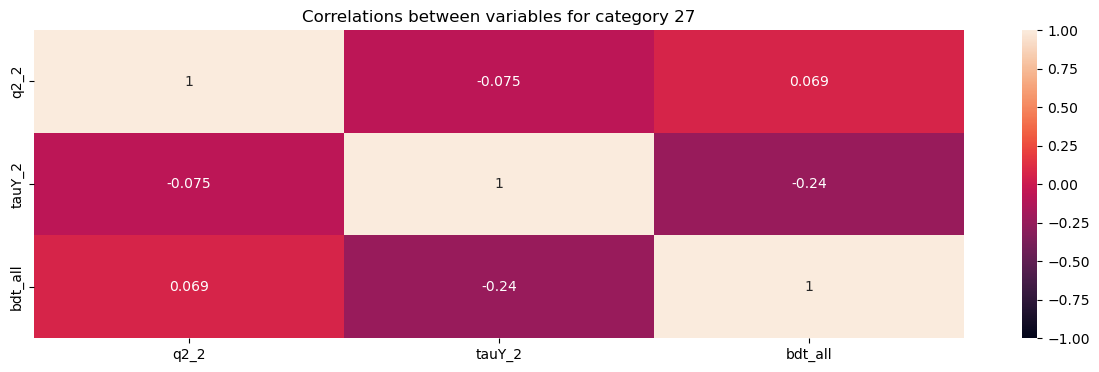

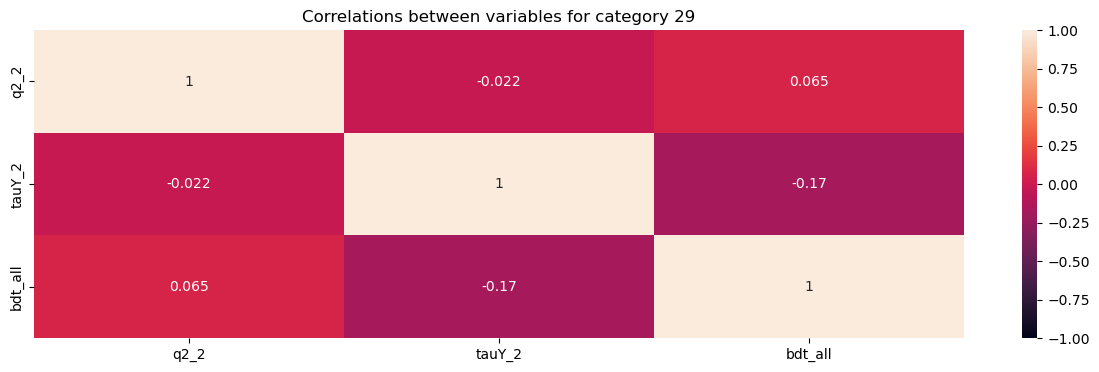

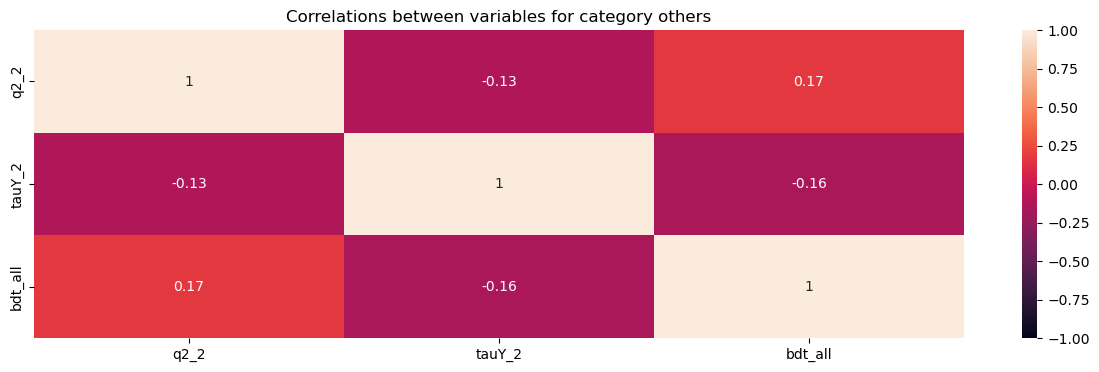

In [6]:
from scipy.stats import pearsonr

def categories_correlation(df, shown_number=17):
    """ The correlations between the categories for variables q2_2, tauY_2, bdt_all """
    
    # Grouping the samples per category
    c = mygroupby(df, 'category')
    c['name'] = c.apply(lambda row: categories[f"{row['category']:.4g}"], axis=1)
    
    # Preparing the list of categories to process
    #shown_number=17
    shown_categs = list(c.head(shown_number)['category'])

    # Building a list of detasets filtered 
    datasets = { f"{c}":  df.query(f"category == {c}") for c in shown_categs }
    datasets["others"] =  df.query(f"category not in {shown_categs}")
    datasets_names = [ f"{c}:" + categories[f"{c}"] for c in shown_categs]
    datasets_names.append("others")
    
    # List of column names
    cols = np.array([ str(c) for c in shown_categs ] + [ "others" ])
    for c in cols:
        df = datasets[c][["q2_2", "tauY_2", "bdt_all"]]
        corr = df.corr()
        plt.figure()
        sn.heatmap(corr, annot=True, vmin=-1.0, vmax=1.0)
        plt.title(f"Correlations between variables for category {c}");
        plt.show()
    
shown_number=17
categories_correlation(df, shown_number)

## Correlations with  CUT1 i.e. BDT_all > 0.75

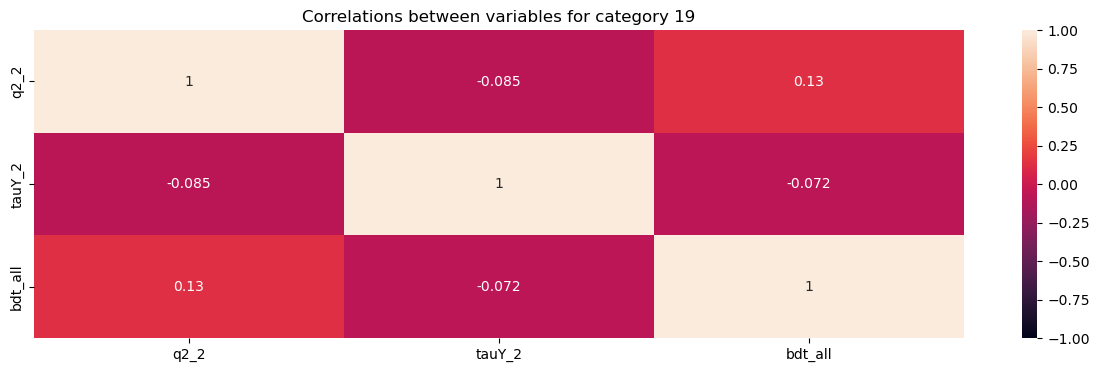

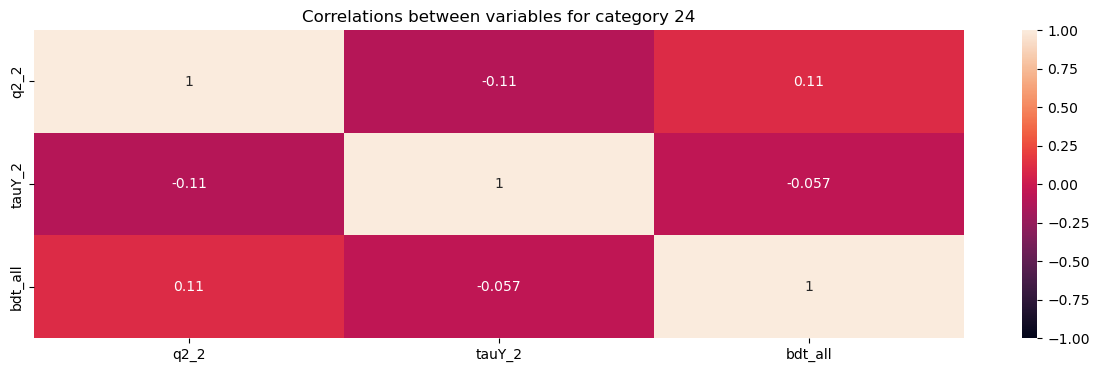

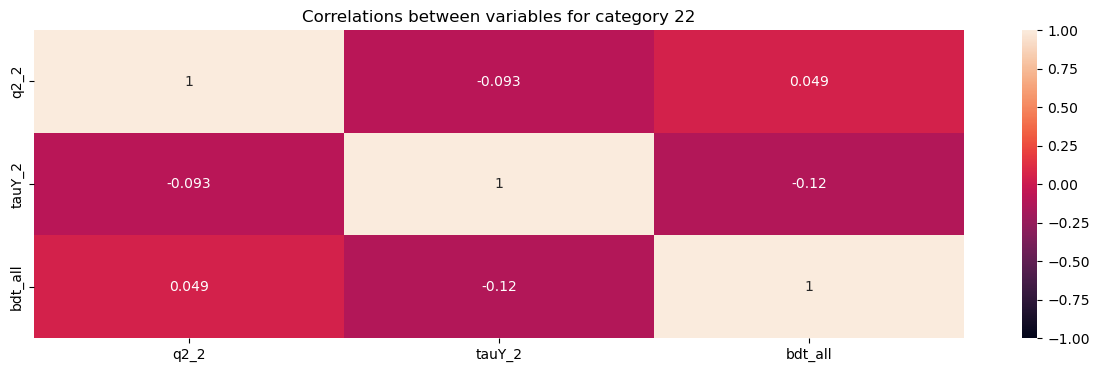

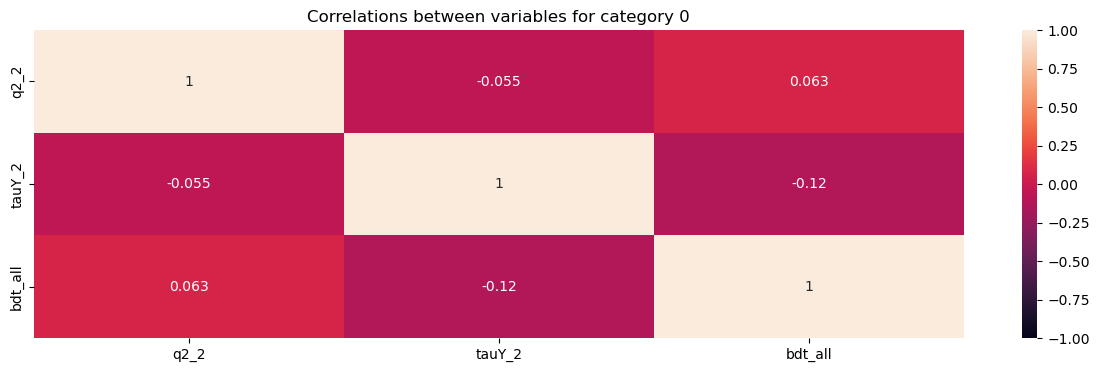

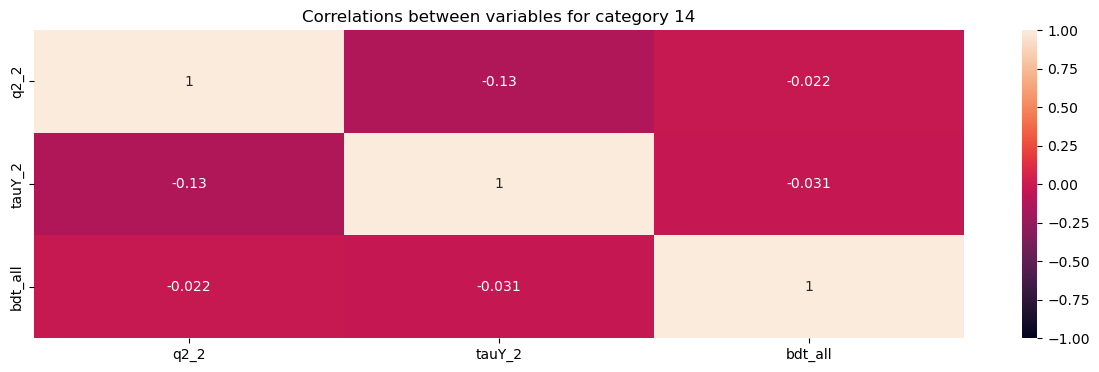

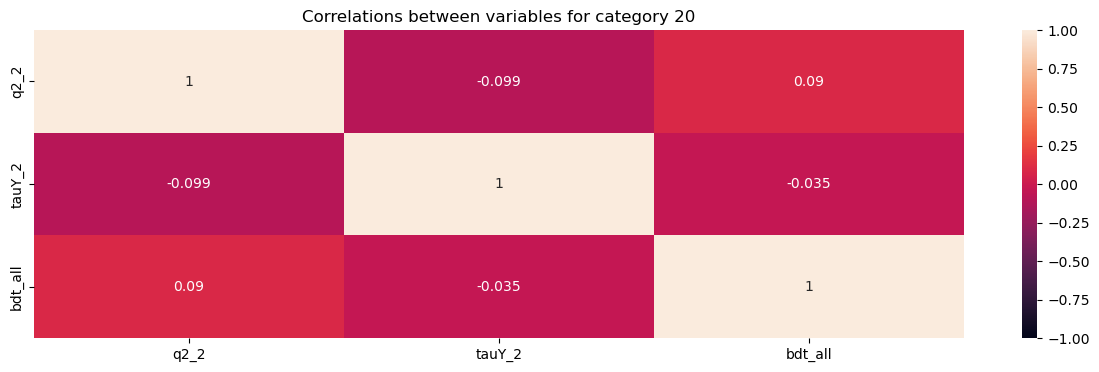

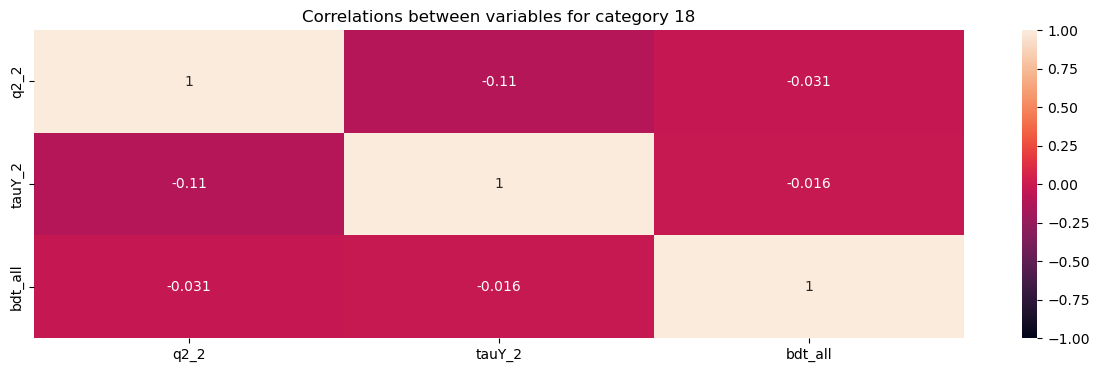

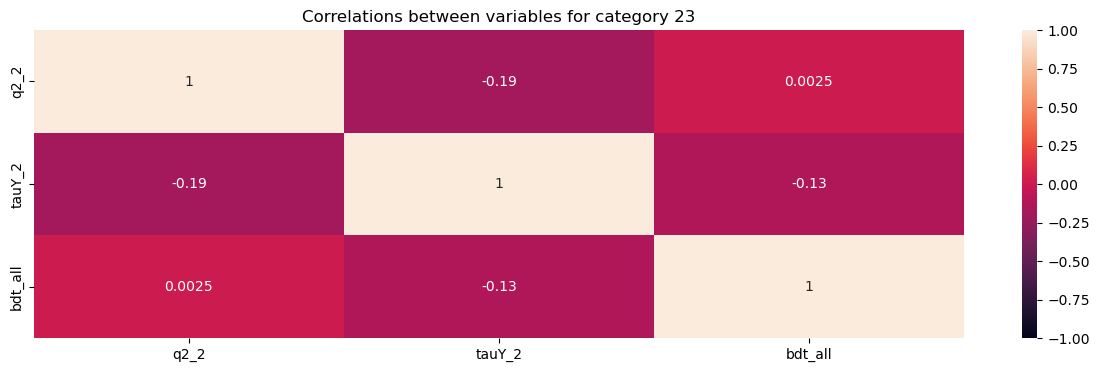

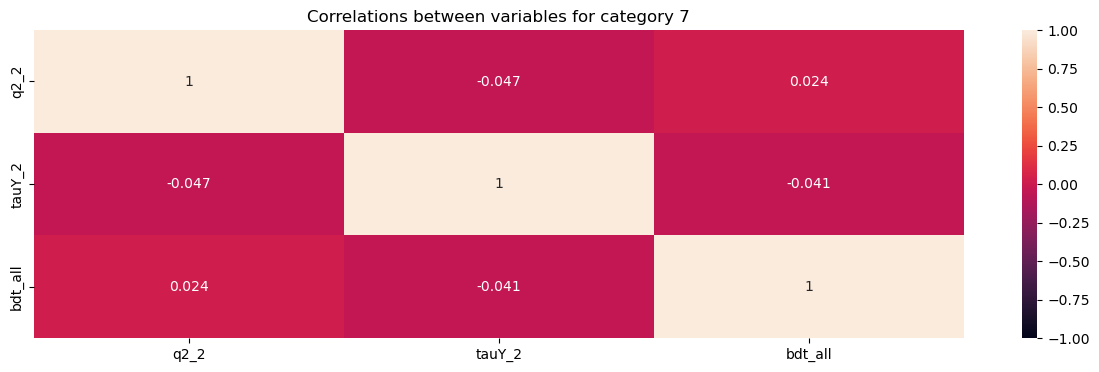

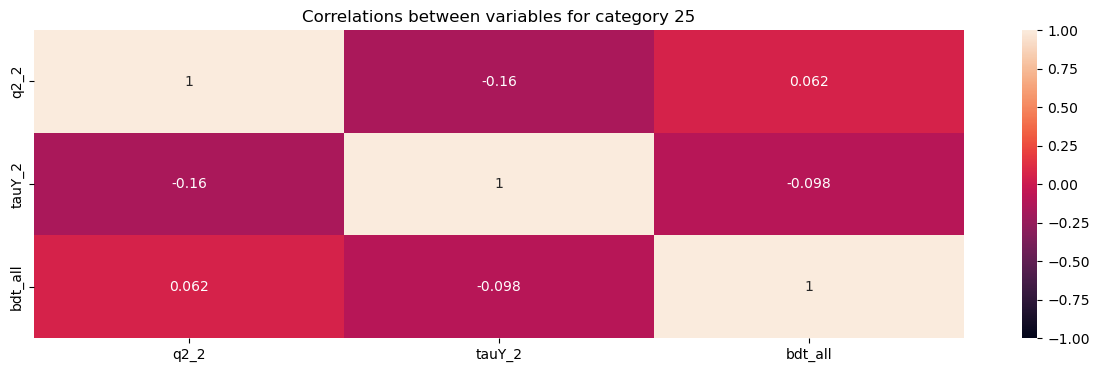

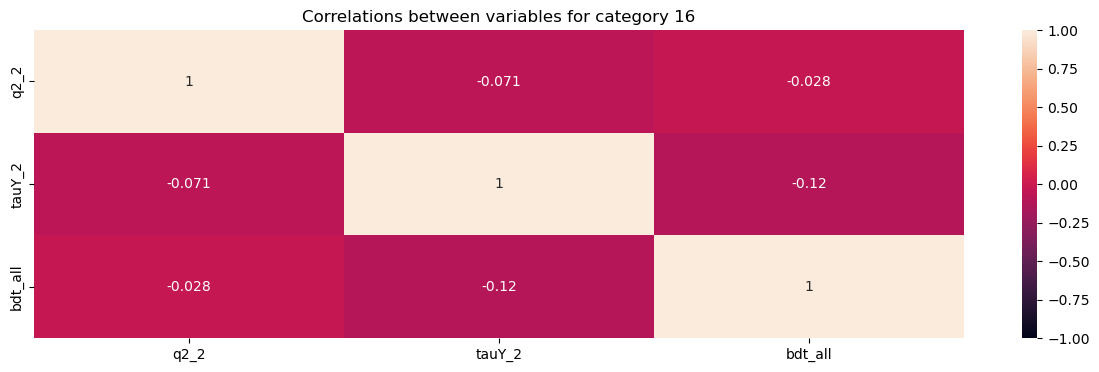

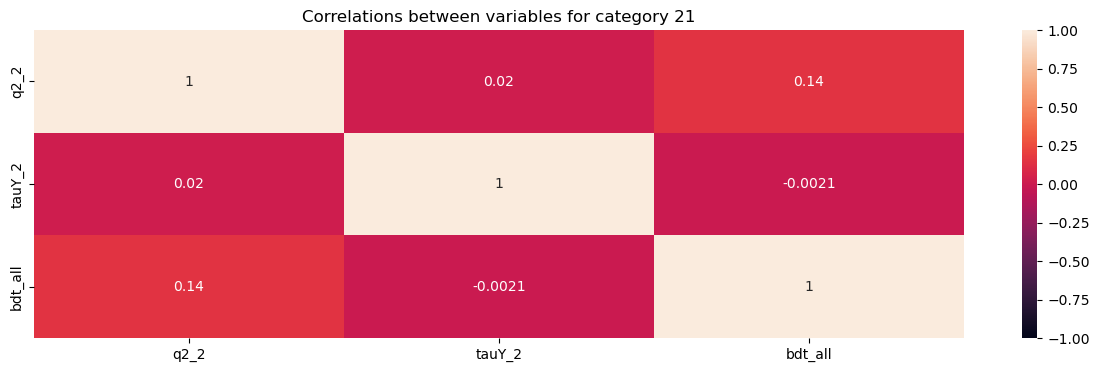

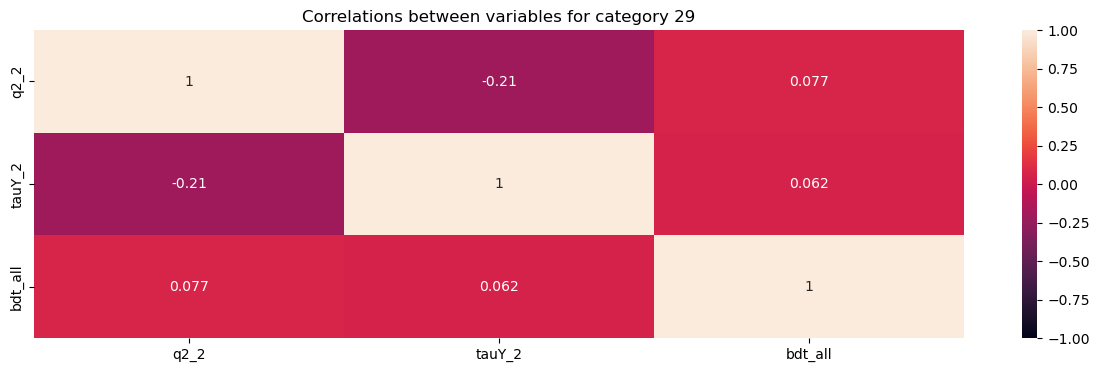

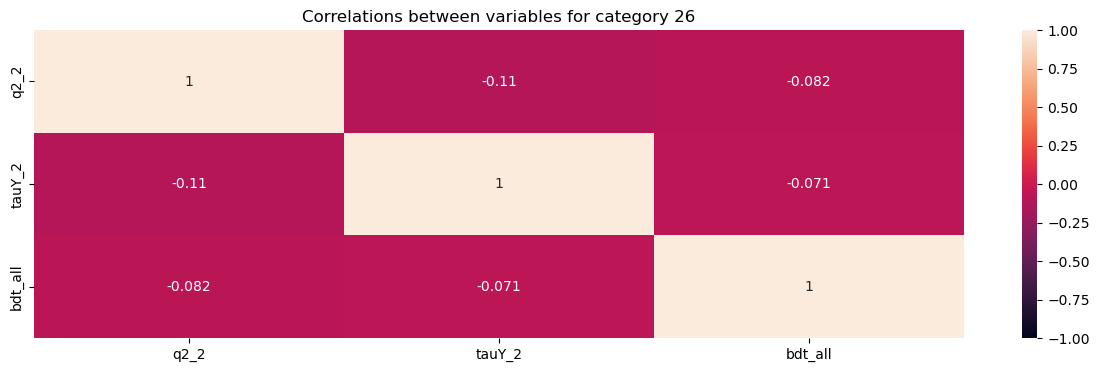

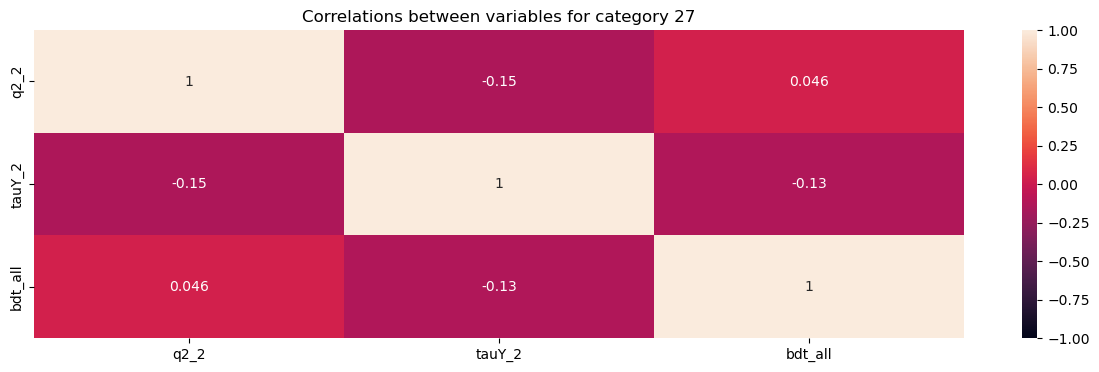

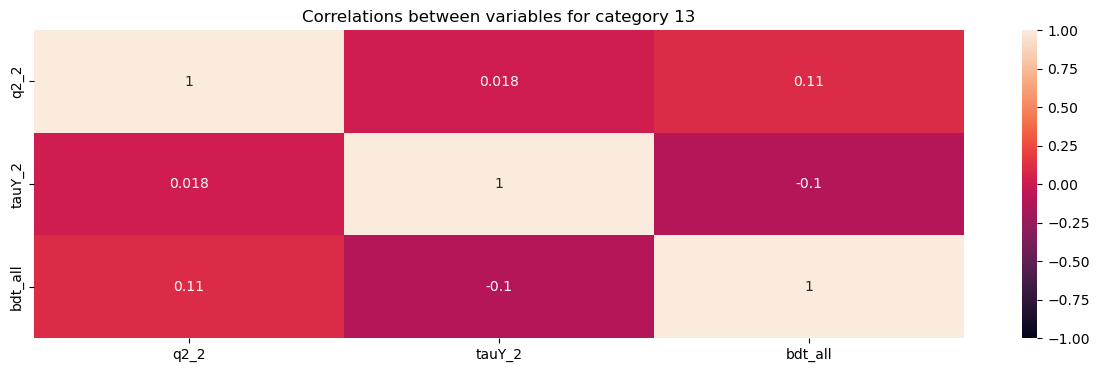

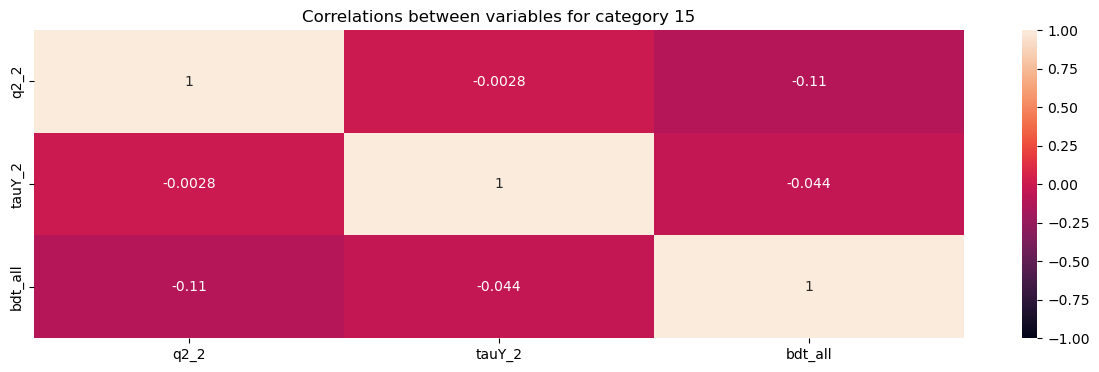

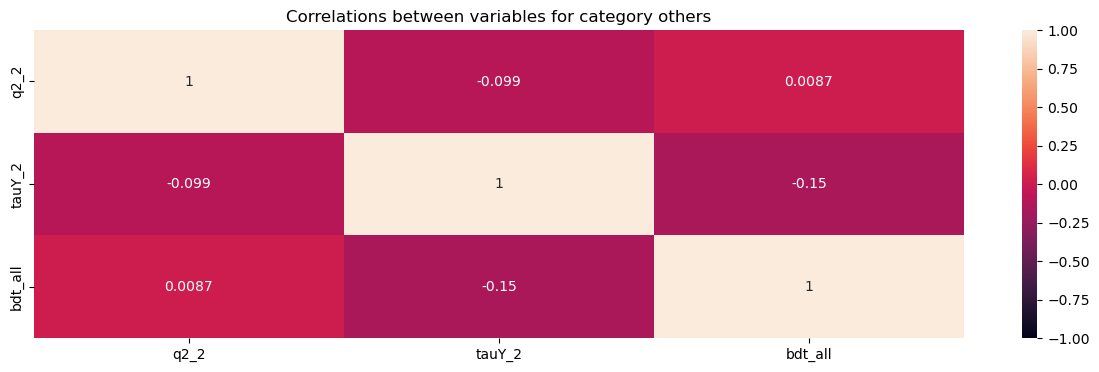

In [7]:
bdt_cutval=0.75
dfcut1 = df.query(f"bdt_all > {bdt_cutval}")
shown_number=17
categories_correlation(dfcut1, shown_number)

## Correlations with  CUT2 i.e. BDT_all > 0.35

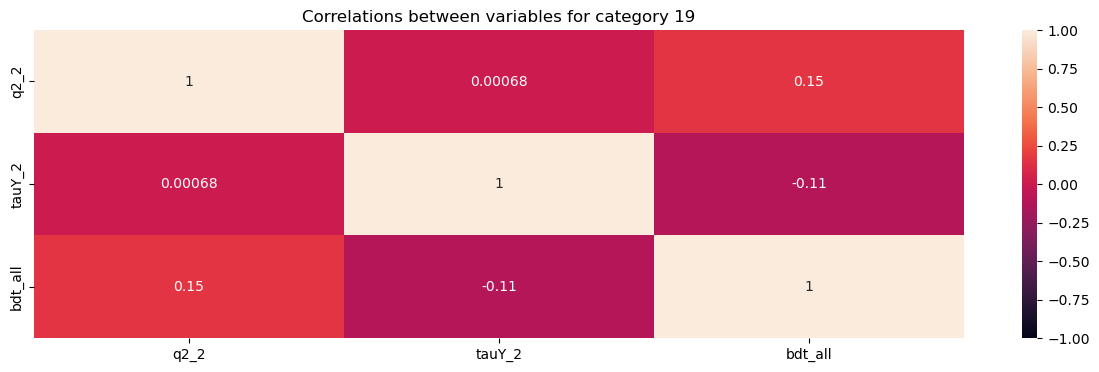

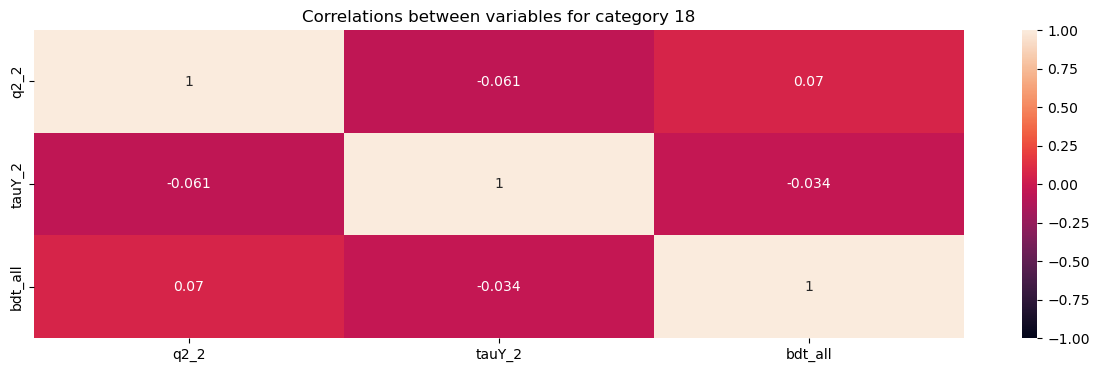

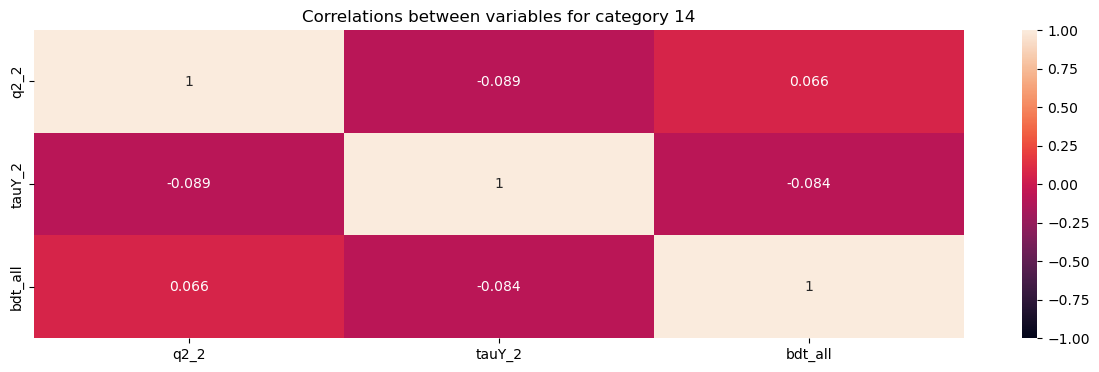

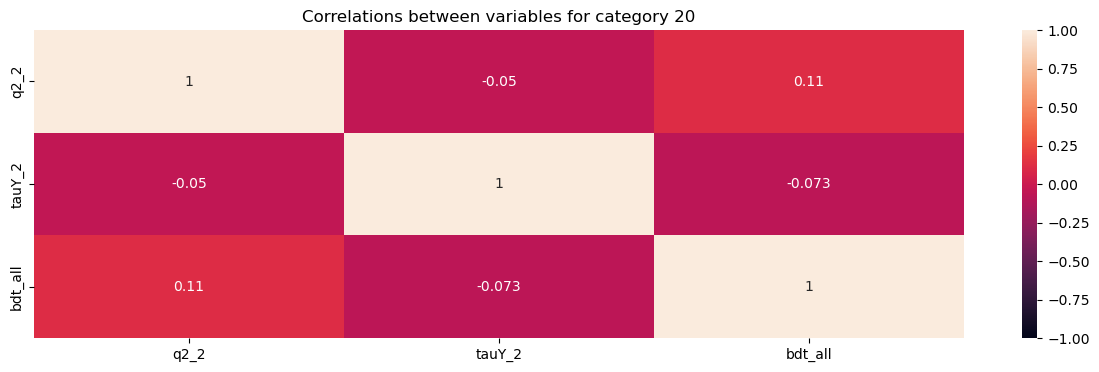

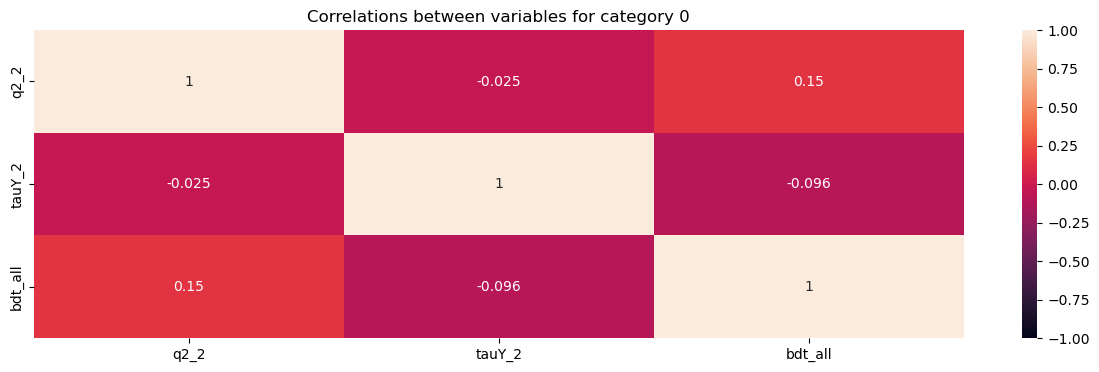

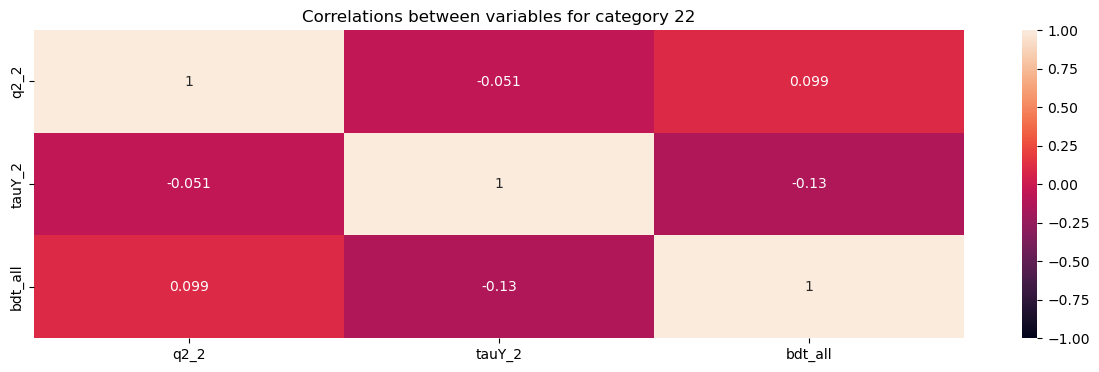

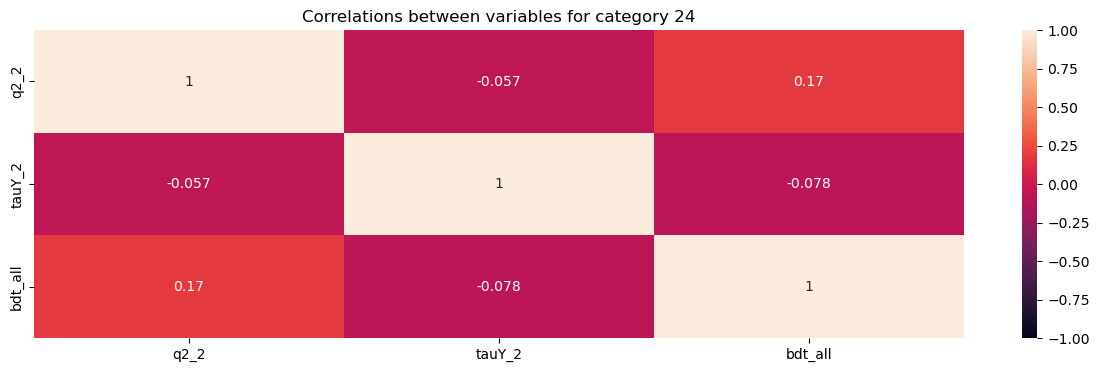

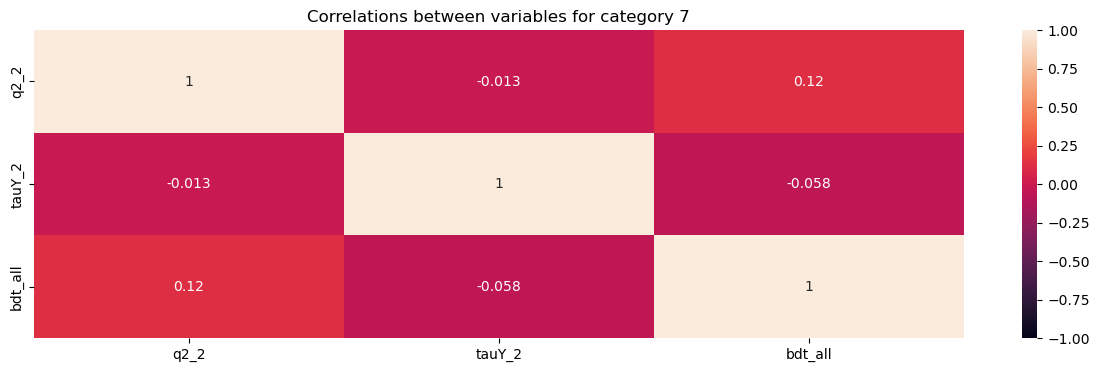

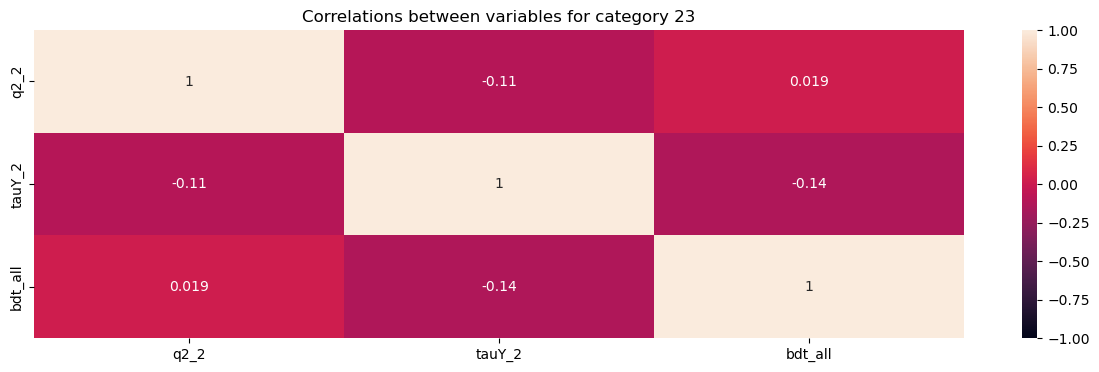

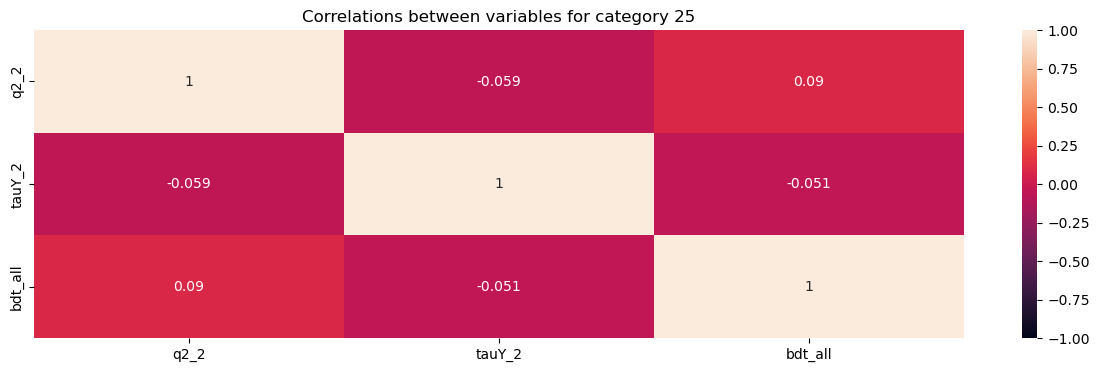

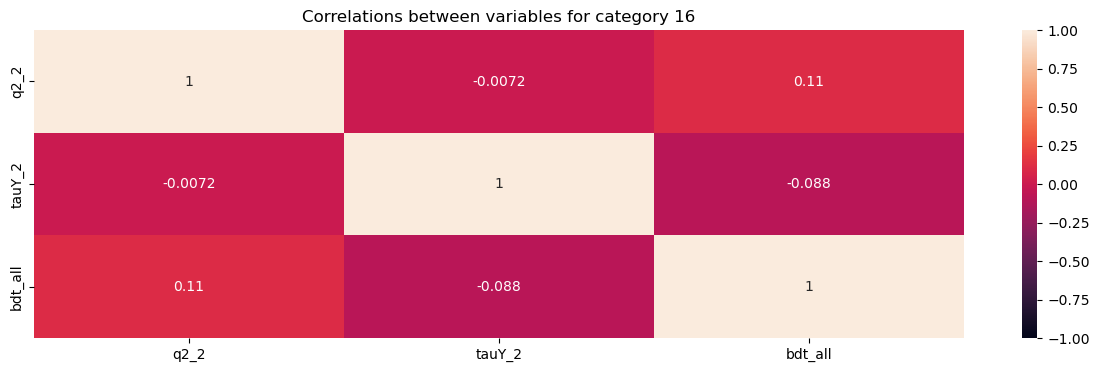

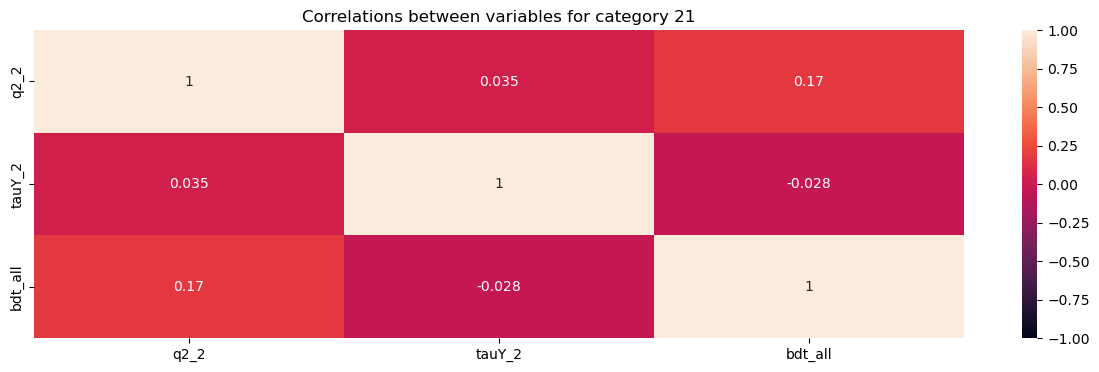

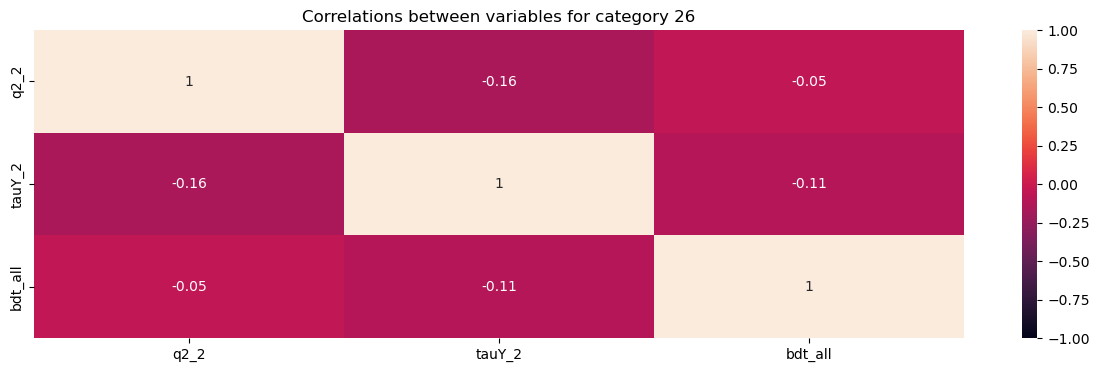

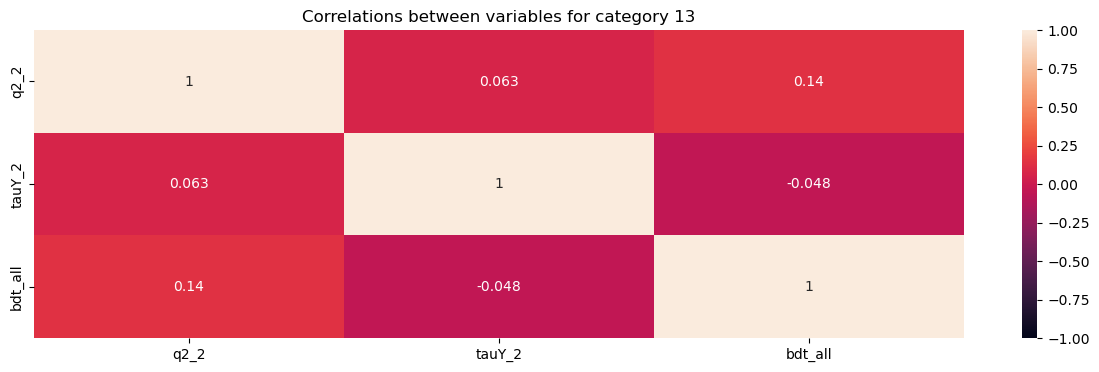

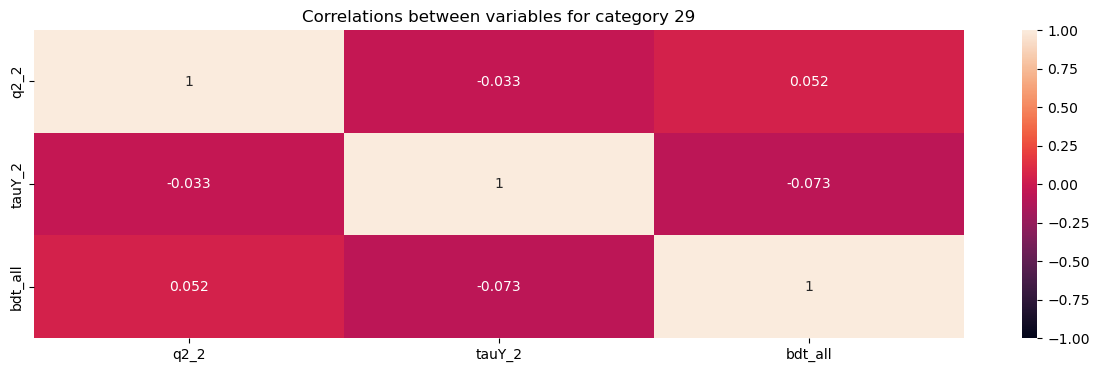

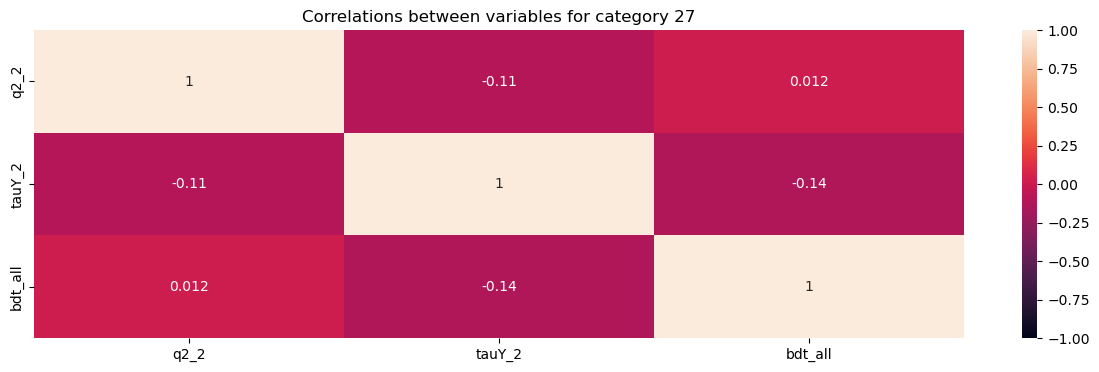

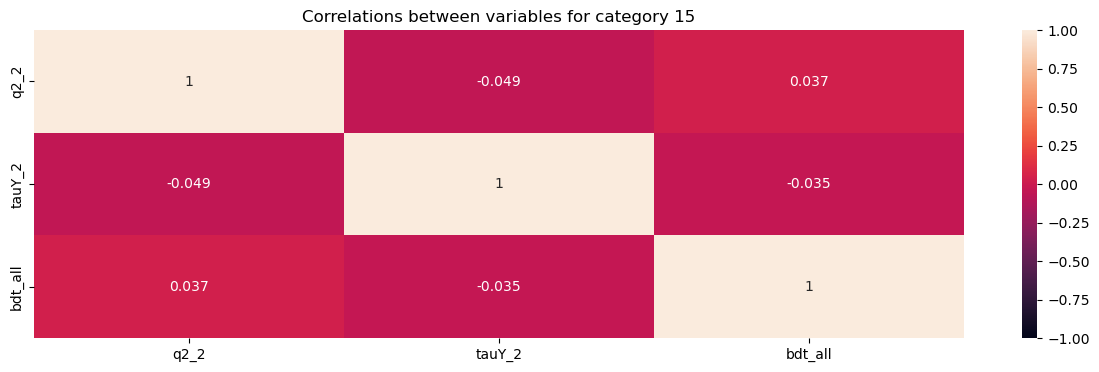

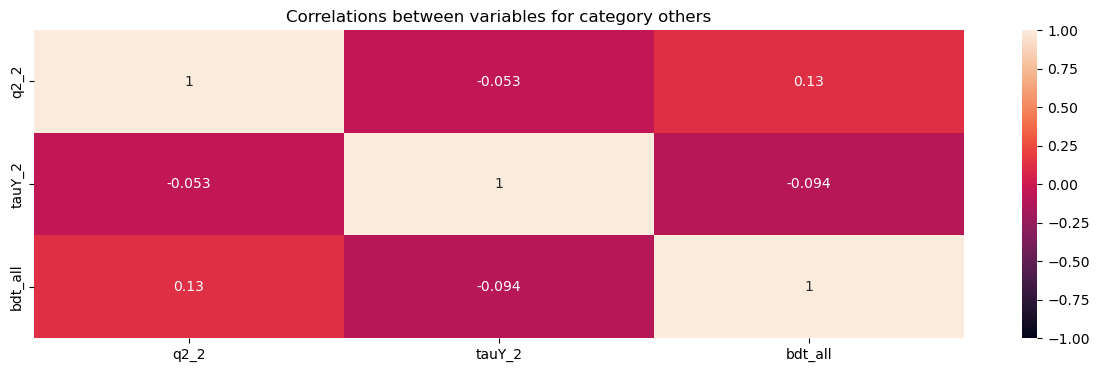

In [8]:
bdt_cutval=0.35
dfcut2 = df.query(f"bdt_all > {bdt_cutval}")
shown_number=17
categories_correlation(dfcut2, shown_number)

## Correlations with  CUT3 i.e. BDT_all > 0.5

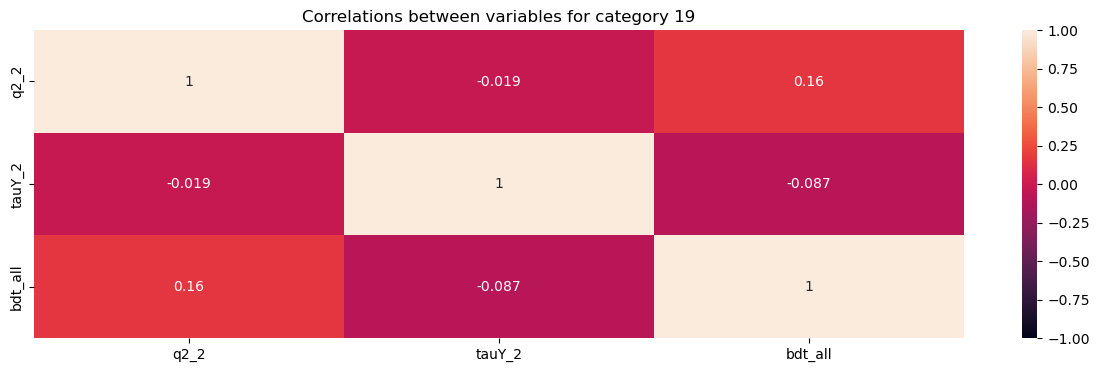

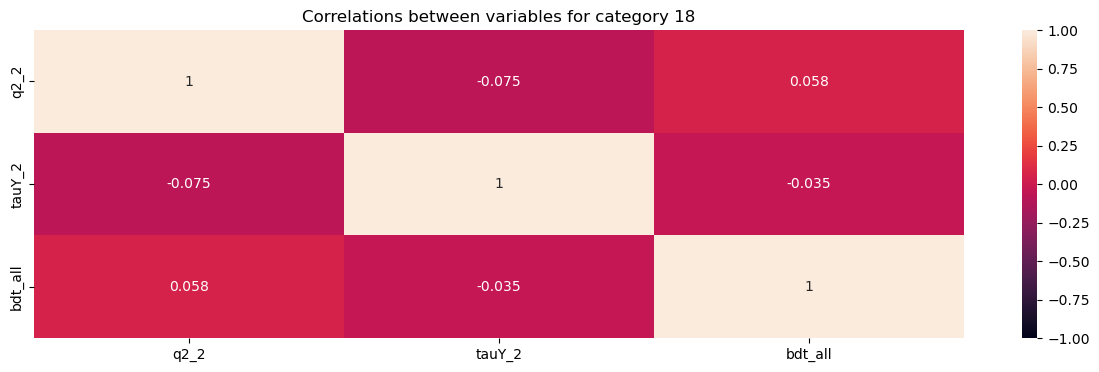

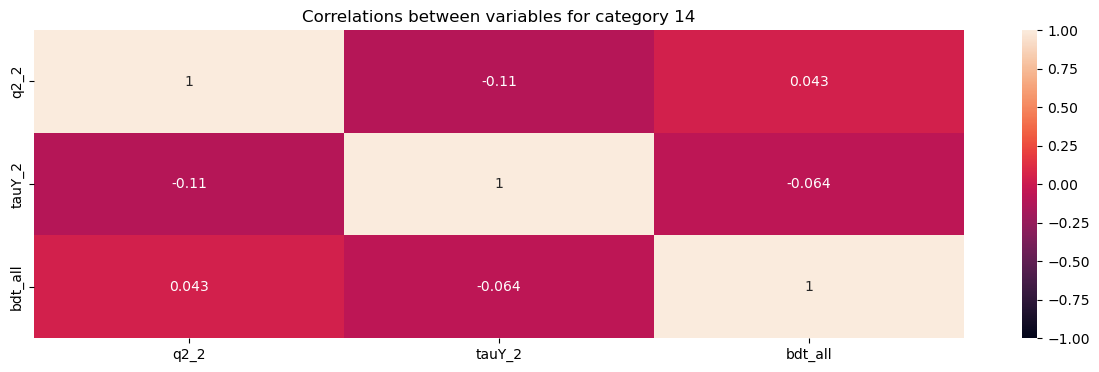

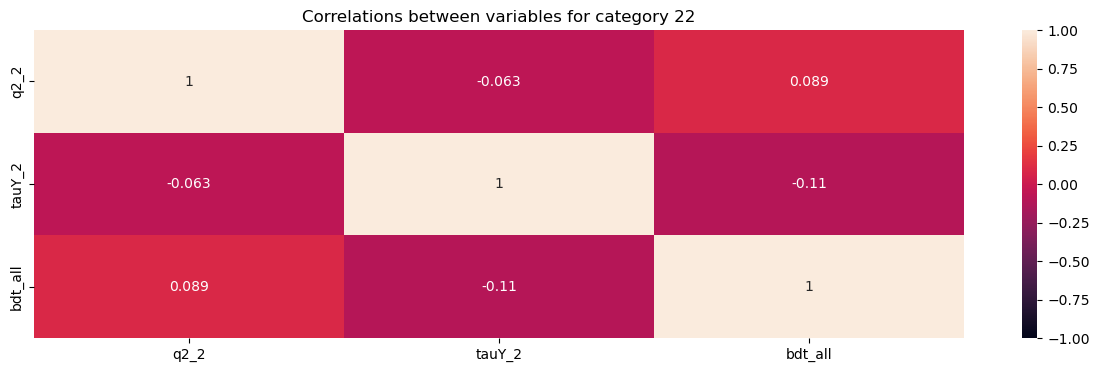

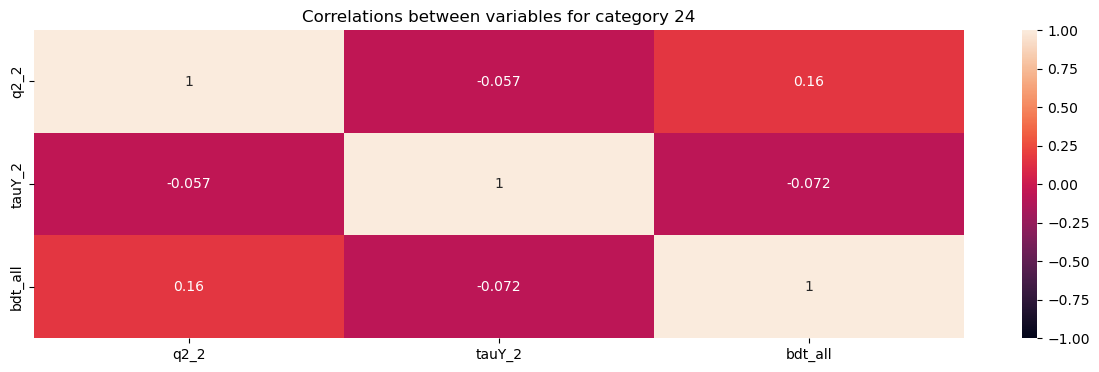

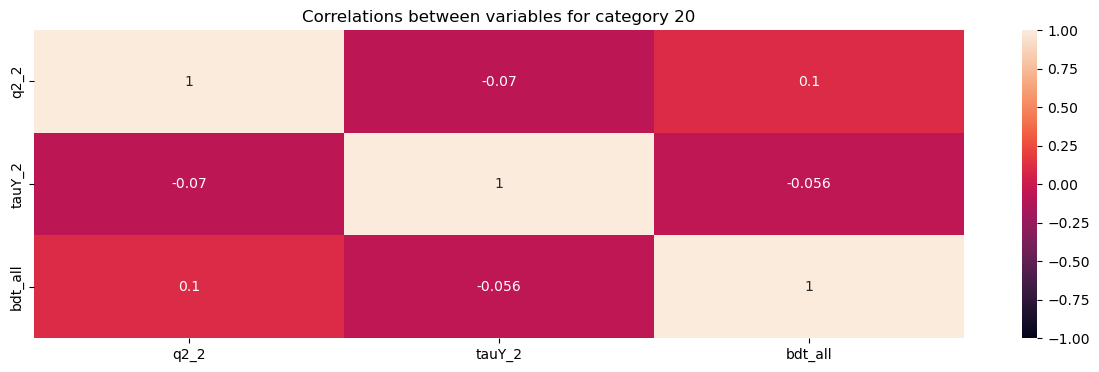

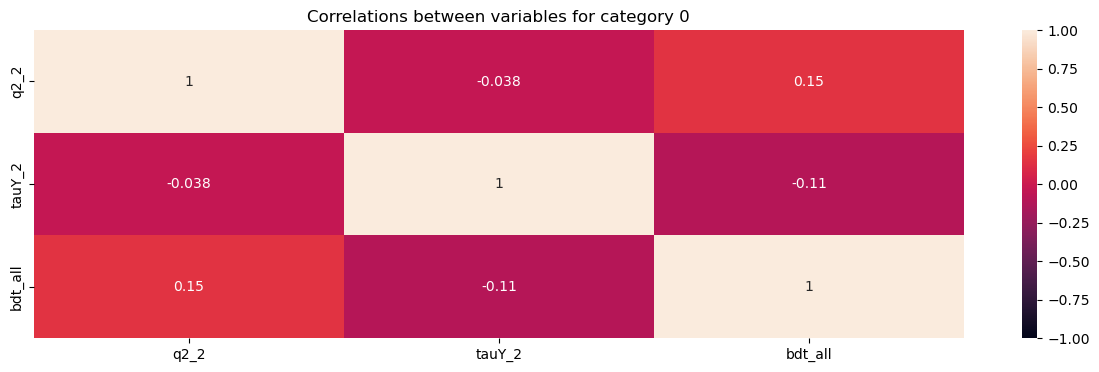

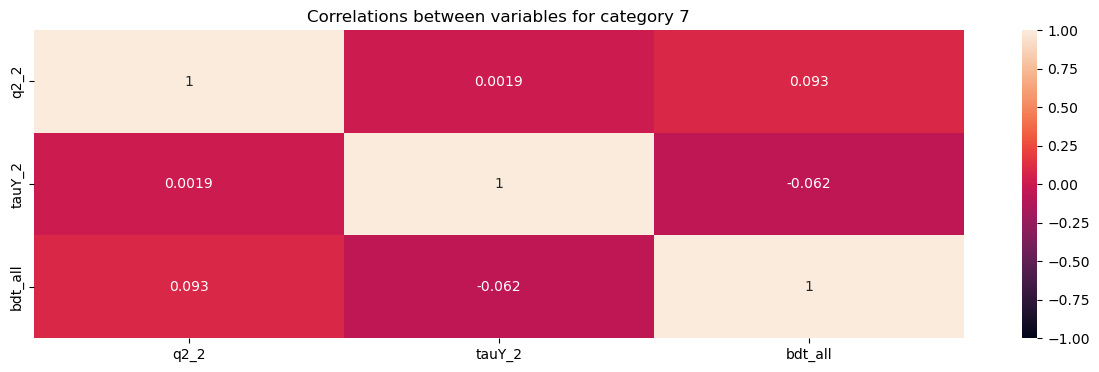

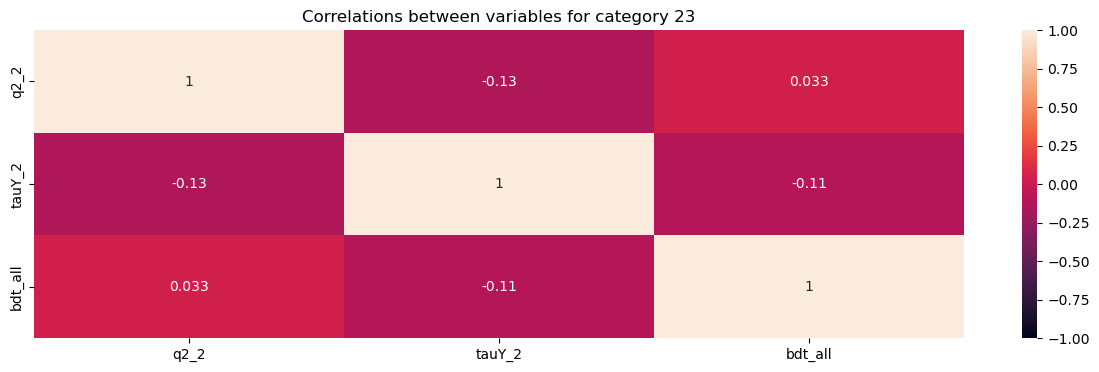

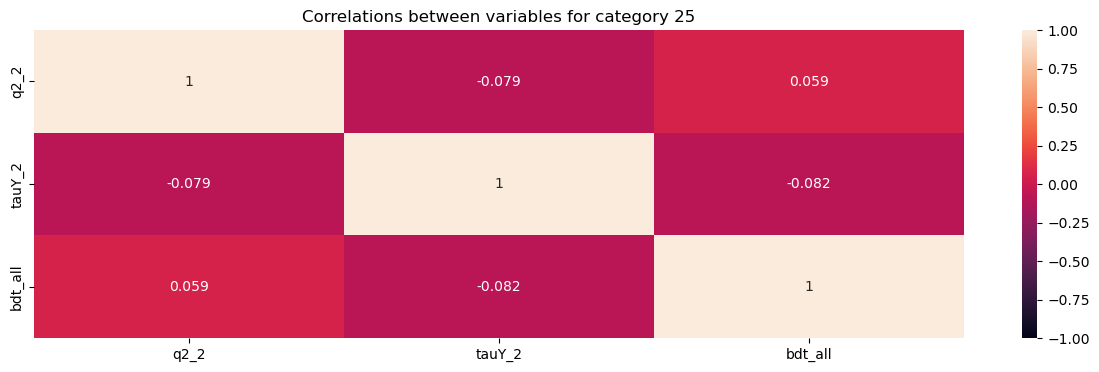

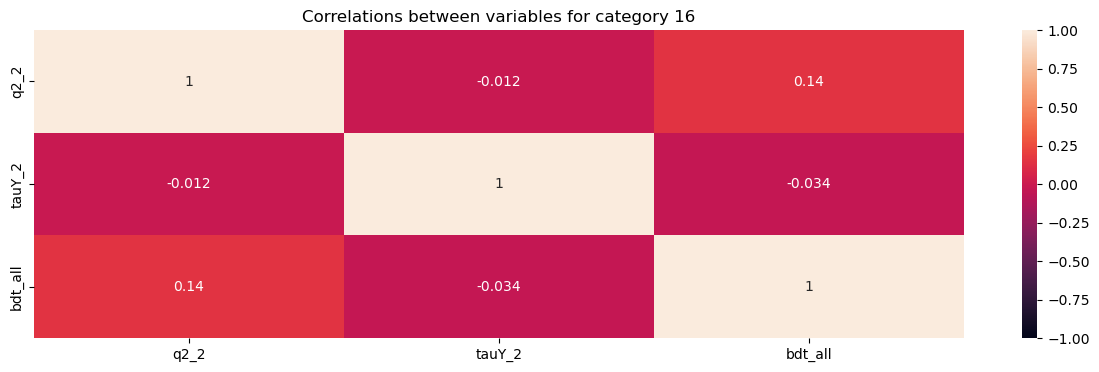

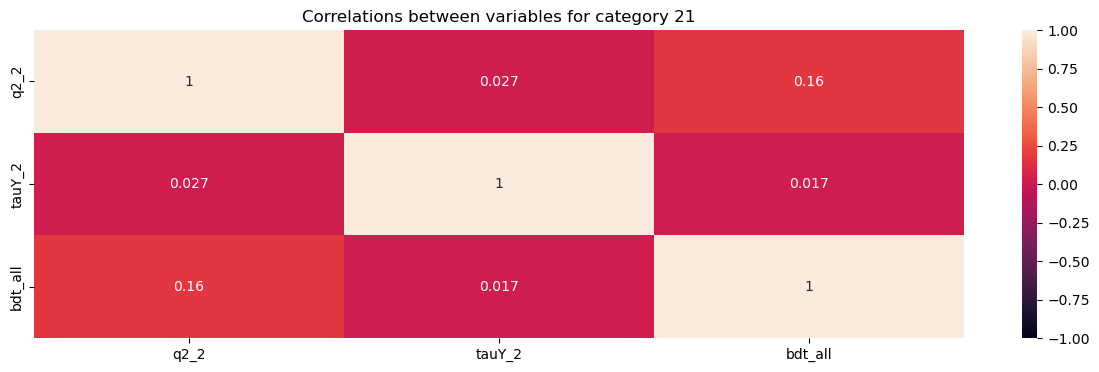

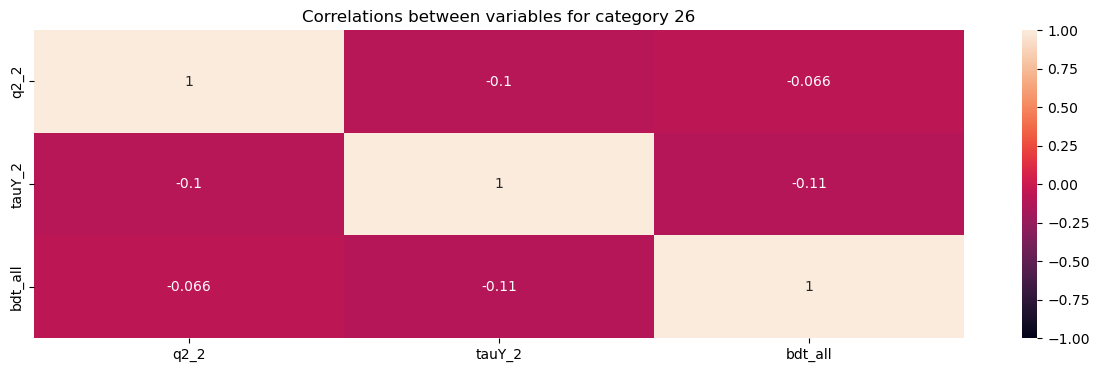

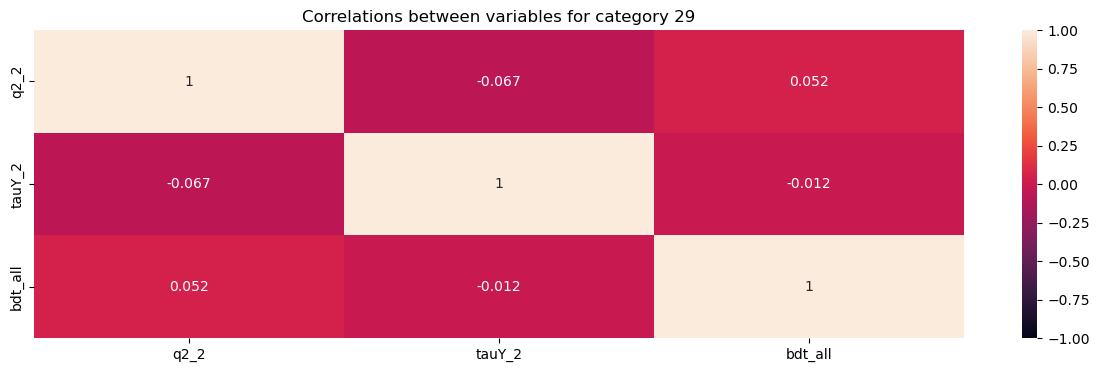

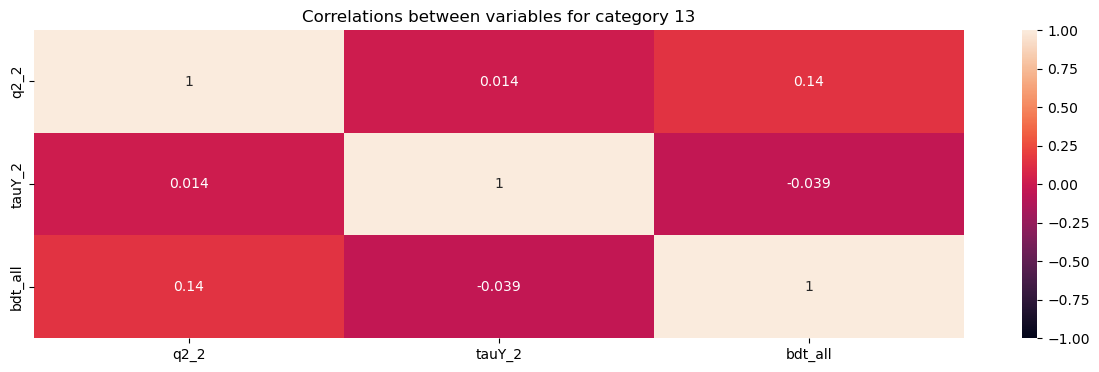

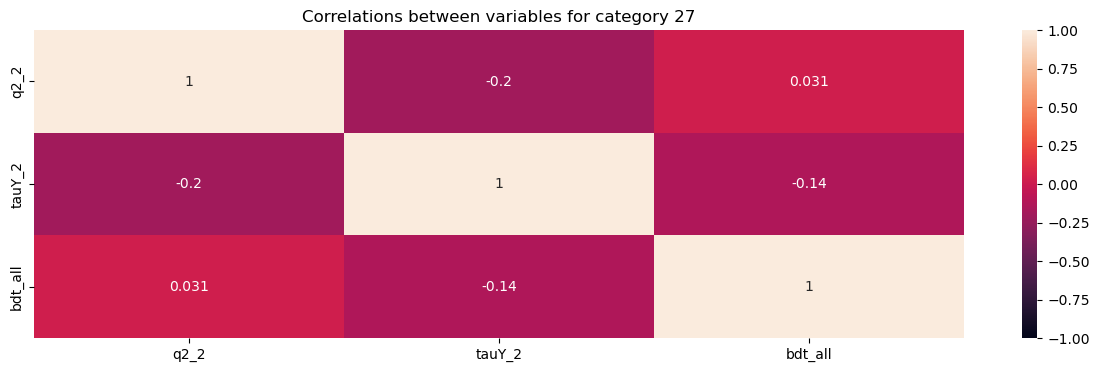

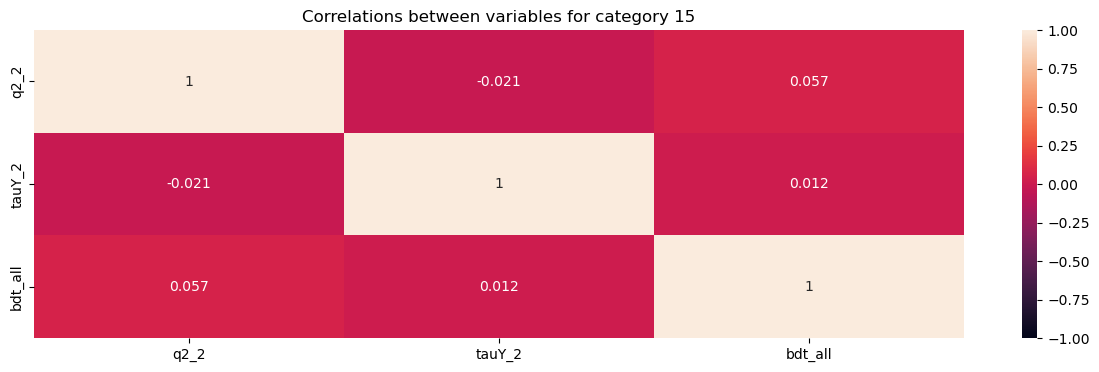

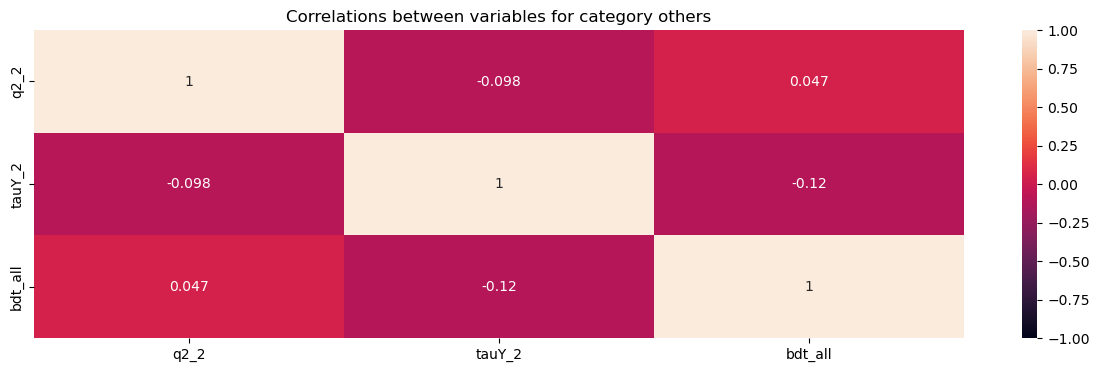

In [9]:
bdt_cutval=0.5
dfcut3 = df.query(f"bdt_all > {bdt_cutval}")
shown_number=17
categories_correlation(dfcut3, shown_number)